# CNN from Scratch vs Transfer Learning untuk Klasifikasi Citra

Nama: Lindi Auliya Habiba

NIM: 452024618089

## Tujuan

Membandingkan performa CNN from Scratch dan Transfer Learning pada tugas klasifikasi citra menggunakan dataset CIFAR-10 dan Cats vs Dogs.

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

# Eksperimen 1 - CNN From Scratch

Dataset yang digunakan adalah CIFAR-10.
Dataset terdiri dari 60.000 gambar berukuran 32x32 piksel dan 10 kelas.

In [7]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


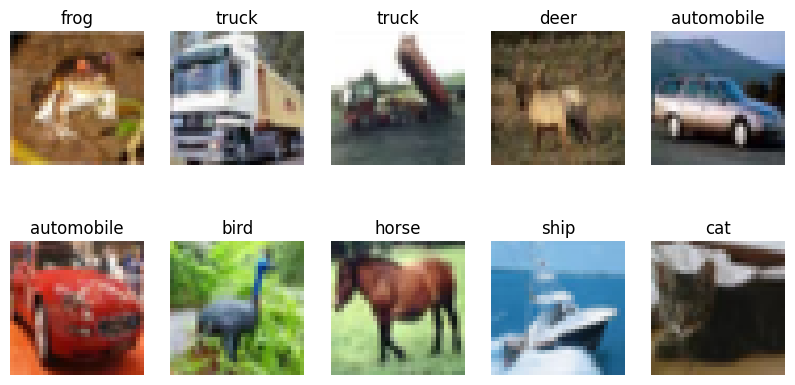

In [8]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

## Preprocessing Data

Normalisasi dilakukan dengan membagi nilai piksel terhadap 255 sehingga rentang nilai menjadi 0–1.

In [9]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Arsitektur CNN

Model terdiri dari:

- 3 Convolution Layer
- 2 Max Pooling Layer
- Flatten Layer
- Dense Layer
- Dropout
- Output Layer

In [10]:
cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training CNN

In [12]:
start_time = time.time()

cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.15
)

cnn_time = time.time() - start_time

print("Training Time:", cnn_time)

Epoch 1/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3944 - loss: 1.6582 - val_accuracy: 0.5344 - val_loss: 1.3141
Epoch 2/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.5379 - loss: 1.3079 - val_accuracy: 0.5896 - val_loss: 1.1775
Epoch 3/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - accuracy: 0.6008 - loss: 1.1396 - val_accuracy: 0.6229 - val_loss: 1.0725
Epoch 4/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.6432 - loss: 1.0272 - val_accuracy: 0.6649 - val_loss: 0.9303
Epoch 5/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.6743 - loss: 0.9390 - val_accuracy: 0.6753 - val_loss: 0.9414
Epoch 6/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.6956 - loss: 0.8762 - val_accuracy: 0.6905 - val_loss: 0.8670
Epoch 7/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - accuracy: 0.7168 - loss: 0.8148 - val_accuracy: 0.7023 - val_loss: 0.8734
Epoch 8/15
1329/1329 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.7317 -

## Evaluasi CNN

In [13]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy :", cnn_test_acc)
print("Test Loss     :", cnn_test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7188 - loss: 0.9313
Test Accuracy : 0.7188000082969666
Test Loss     : 0.9313098788261414


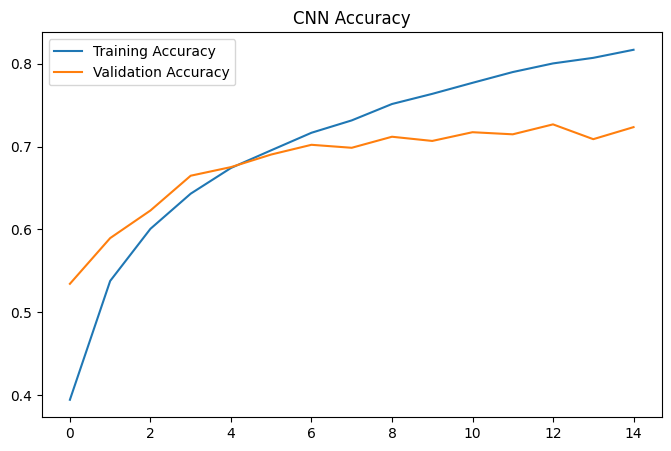

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.legend()
plt.title("CNN Accuracy")
plt.show()

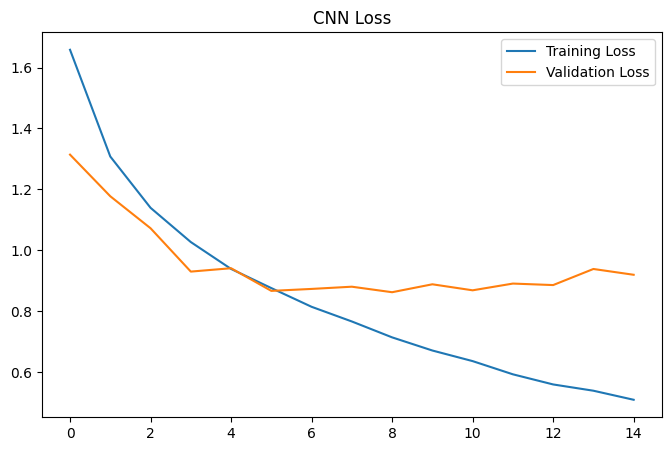

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    cnn_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='Validation Loss'
)

plt.legend()
plt.title("CNN Loss")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


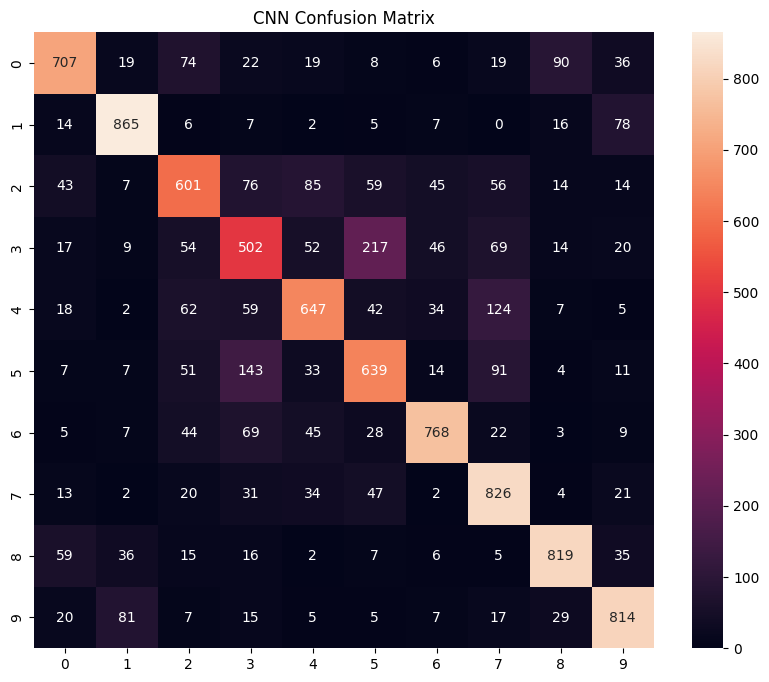

In [16]:
cnn_pred = cnn_model.predict(X_test)

cnn_pred_class = np.argmax(
    cnn_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    cnn_pred_class
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("CNN Confusion Matrix")
plt.show()

# Eksperimen 2 - Transfer Learning

Model yang digunakan adalah MobileNetV2 dengan strategi Feature Extraction.

In [17]:
import tensorflow_datasets as tfds

dataset, info = tfds.load(
    "cats_vs_dogs",
    with_info=True,
    as_supervised=True
)

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.1YVYO2_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

In [18]:
IMG_SIZE = 224

def preprocess(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = image / 255.0

    return image, label

In [19]:
dataset = dataset['train']

dataset = dataset.map(preprocess)

In [20]:
dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)

val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

BATCH_SIZE = 32

train_ds = train_ds.batch(BATCH_SIZE)
val_ds = val_ds.batch(BATCH_SIZE)
test_ds = test_ds.batch(BATCH_SIZE)

In [21]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [22]:
transfer_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )
])

transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
transfer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
start_time = time.time()

transfer_history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

transfer_time = time.time() - start_time

Epoch 1/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 473s 920ms/step - accuracy: 0.9747 - loss: 0.0716 - val_accuracy: 0.9825 - val_loss: 0.0502
Epoch 2/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 516s 1s/step - accuracy: 0.9816 - loss: 0.0473 - val_accuracy: 0.9825 - val_loss: 0.0454
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 497s 978ms/step - accuracy: 0.9857 - loss: 0.0395 - val_accuracy: 0.9851 - val_loss: 0.0408
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 504s 990ms/step - accuracy: 0.9875 - loss: 0.0337 - val_accuracy: 0.9848 - val_loss: 0.0428
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 529s 1s/step - accuracy: 0.9885 - loss: 0.0314 - val_accuracy: 0.9848 - val_loss: 0.0425


In [25]:
transfer_loss, transfer_acc = transfer_model.evaluate(
    test_ds
)

print("Test Accuracy :", transfer_acc)

110/110 ━━━━━━━━━━━━━━━━━━━━ 103s 782ms/step - accuracy: 0.9840 - loss: 0.0378
Test Accuracy : 0.983954131603241


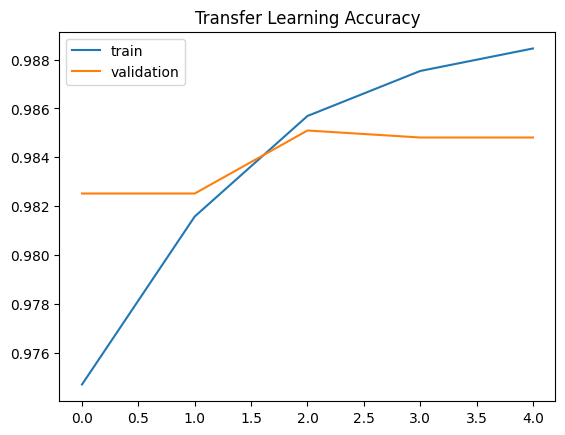

In [26]:
plt.plot(
    transfer_history.history['accuracy']
)

plt.plot(
    transfer_history.history['val_accuracy']
)

plt.legend([
    'train',
    'validation'
])

plt.title("Transfer Learning Accuracy")
plt.show()

# Perbandingan Model

In [37]:
comparison = pd.DataFrame({

    "Aspek":[
        "Training Accuracy",
        "Validation Accuracy",
        "Testing Accuracy",
        "Training Loss",
        "Validation Loss",
        "Training Time (s)",
        "Parameters"
    ],

    "CNN":[
        max(cnn_history.history['accuracy']),
        max(cnn_history.history['val_accuracy']),
        cnn_test_acc,
        min(cnn_history.history['loss']),
        min(cnn_history.history['val_loss']),
        cnn_time,
        cnn_model.count_params()
    ],

    "Transfer Learning":[
        max(transfer_history.history['accuracy']),
        max(transfer_history.history['val_accuracy']),
        transfer_acc,
        min(transfer_history.history['loss']),
        min(transfer_history.history['val_loss']),
        transfer_time,
        transfer_model.count_params()
    ]
})

comparison

,Aspek,CNN,Transfer Learning
0,Training Accuracy,0.817012,9.884542e-01
1,Validation Accuracy,0.726933,9.850960e-01
2,Testing Accuracy,0.718800,9.839541e-01
3,Training Loss,0.509682,3.141807e-02
4,Validation Loss,0.862624,4.083407e-02
5,Training Time (s),603.340365,2.552013e+03
6,Parameters,356810.000000,2.422081e+06


## Evaluasi Transfer Learning (Lanjutan)

110/110 ━━━━━━━━━━━━━━━━━━━━ 105s 791ms/step


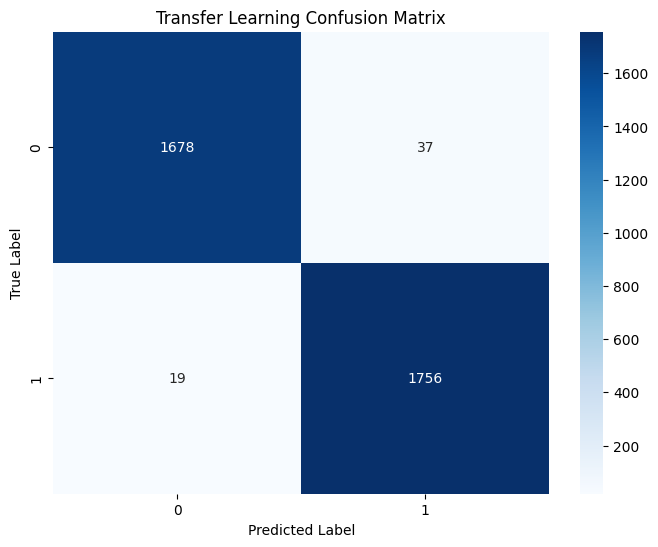

In [28]:
# Get predictions for Transfer Learning model
transfer_pred = transfer_model.predict(test_ds)
transfer_pred_class = np.round(transfer_pred).flatten().astype(int)

# Extract true labels from test_ds
true_labels = []
for _, labels in test_ds.unbatch().as_numpy_iterator():
    true_labels.append(labels)
true_labels = np.array(true_labels)

# Generate confusion matrix
cm_transfer = confusion_matrix(
    true_labels,
    transfer_pred_class
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_transfer,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Transfer Learning Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Prediksi Benar/Salah CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


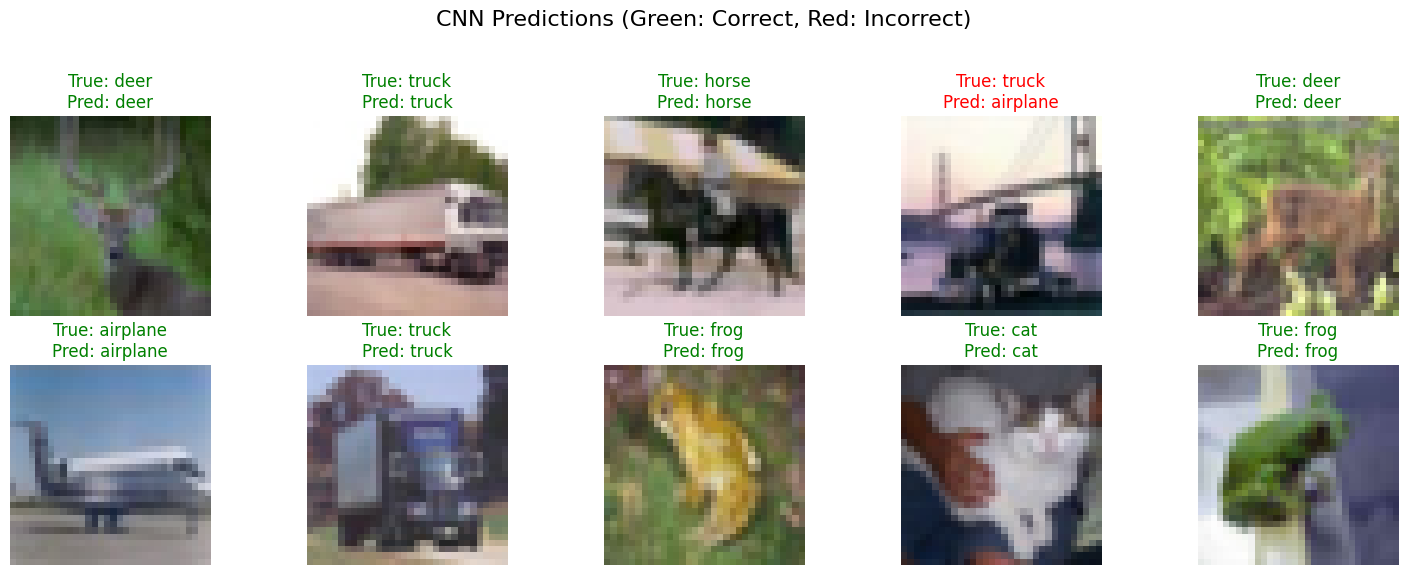

In [29]:
# Select some random samples from X_test
num_samples_to_show = 10
random_indices = np.random.choice(len(X_test), num_samples_to_show, replace=False)

cnn_sample_images = X_test[random_indices]
cnn_sample_true_labels = y_test[random_indices]
cnn_sample_predictions = cnn_model.predict(cnn_sample_images)
cnn_sample_predicted_classes = np.argmax(cnn_sample_predictions, axis=1)

plt.figure(figsize=(15, 6))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(cnn_sample_images[i])
    true_label_name = class_names[cnn_sample_true_labels[i][0]]
    predicted_label_name = class_names[cnn_sample_predicted_classes[i]]

    color = 'green' if true_label_name == predicted_label_name else 'red'
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color)
    plt.axis('off')
plt.suptitle('CNN Predictions (Green: Correct, Red: Incorrect)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Contoh Prediksi Benar CNN

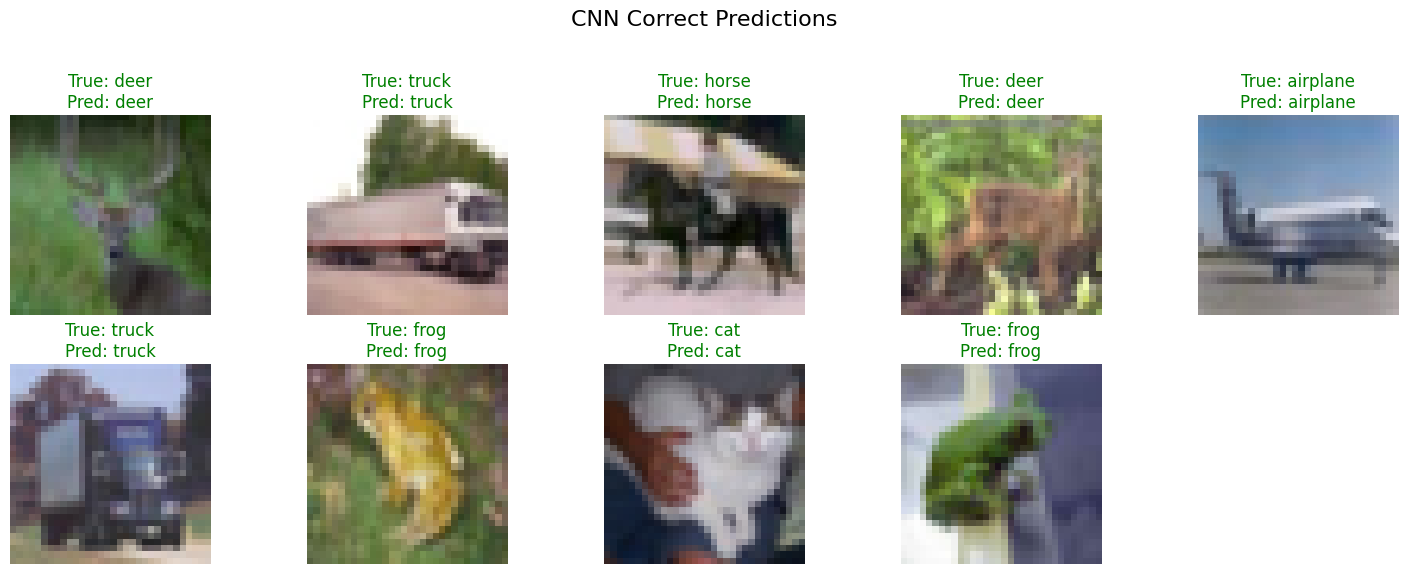

In [32]:
# Filter for correct predictions
correct_cnn_indices = np.where(cnn_sample_true_labels.flatten() == cnn_sample_predicted_classes)[0]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(correct_cnn_indices[:10]): # Show up to 10 correct predictions
    plt.subplot(2, 5, i + 1)
    plt.imshow(cnn_sample_images[idx])
    true_label_name = class_names[cnn_sample_true_labels[idx][0]]
    predicted_label_name = class_names[cnn_sample_predicted_classes[idx]]
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color='green')
    plt.axis('off')
plt.suptitle('CNN Correct Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Contoh Prediksi Salah CNN

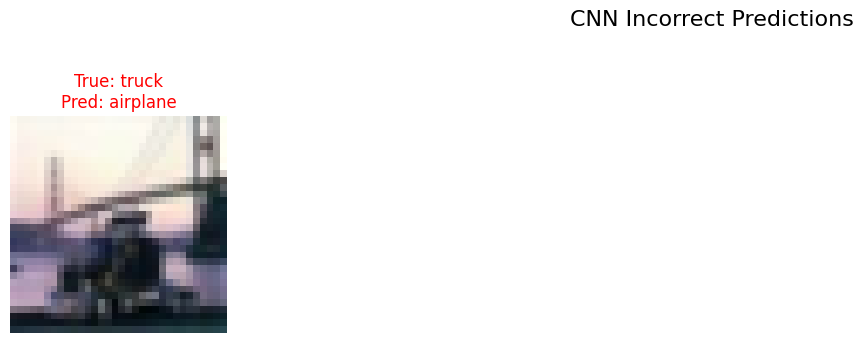

In [33]:
# Filter for incorrect predictions
incorrect_cnn_indices = np.where(cnn_sample_true_labels.flatten() != cnn_sample_predicted_classes)[0]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(incorrect_cnn_indices[:10]): # Show up to 10 incorrect predictions
    plt.subplot(2, 5, i + 1)
    plt.imshow(cnn_sample_images[idx])
    true_label_name = class_names[cnn_sample_true_labels[idx][0]]
    predicted_label_name = class_names[cnn_sample_predicted_classes[idx]]
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color='red')
    plt.axis('off')
plt.suptitle('CNN Incorrect Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Prediksi Benar/Salah Transfer Learning

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


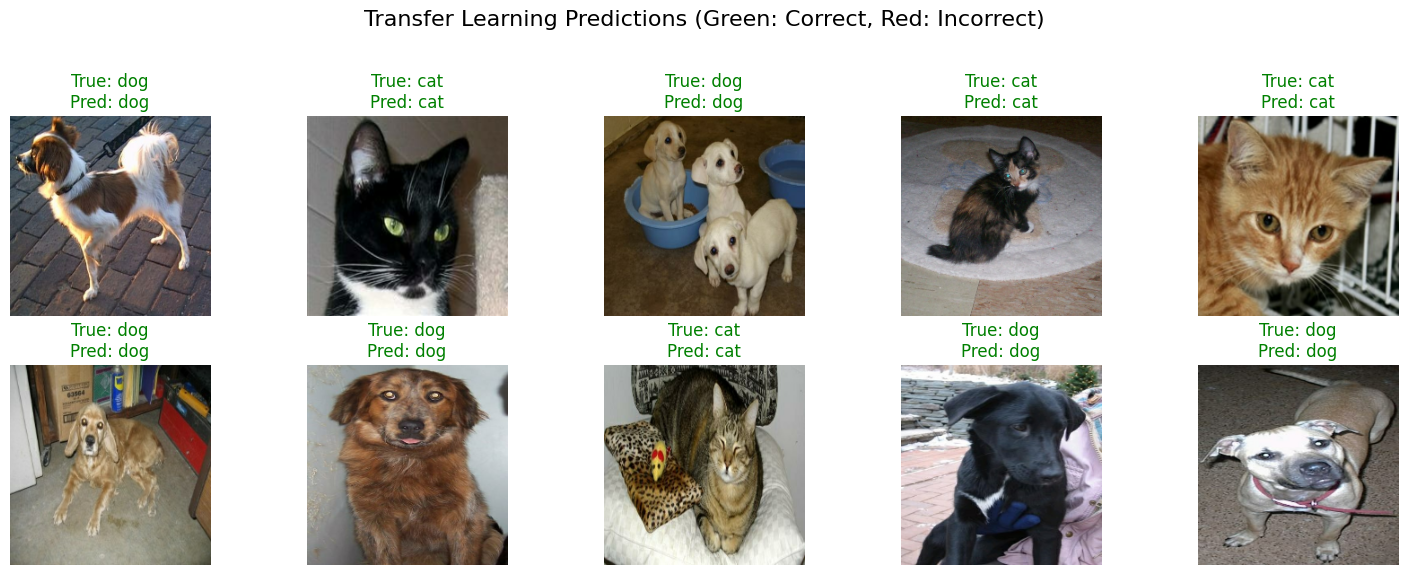

In [30]:
transfer_class_names = info.features['label'].names # ['cat', 'dog']

# Get a few samples from the test_ds
num_samples_to_show_transfer = 10
sample_images_transfer = []
sample_true_labels_transfer = []

for img, label in test_ds.unbatch().take(num_samples_to_show_transfer):
    sample_images_transfer.append(img.numpy())
    sample_true_labels_transfer.append(label.numpy())

sample_images_transfer = np.array(sample_images_transfer)
sample_true_labels_transfer = np.array(sample_true_labels_transfer)

transfer_sample_predictions = transfer_model.predict(sample_images_transfer)
transfer_sample_predicted_classes = np.round(transfer_sample_predictions).flatten().astype(int)

plt.figure(figsize=(15, 6))
for i in range(num_samples_to_show_transfer):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images_transfer[i])
    true_label_name_transfer = transfer_class_names[sample_true_labels_transfer[i]]
    predicted_label_name_transfer = transfer_class_names[transfer_sample_predicted_classes[i]]

    color = 'green' if true_label_name_transfer == predicted_label_name_transfer else 'red'
    plt.title(f"True: {true_label_name_transfer}\nPred: {predicted_label_name_transfer}", color=color)
    plt.axis('off')
plt.suptitle('Transfer Learning Predictions (Green: Correct, Red: Incorrect)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Contoh Prediksi Benar Transfer Learning

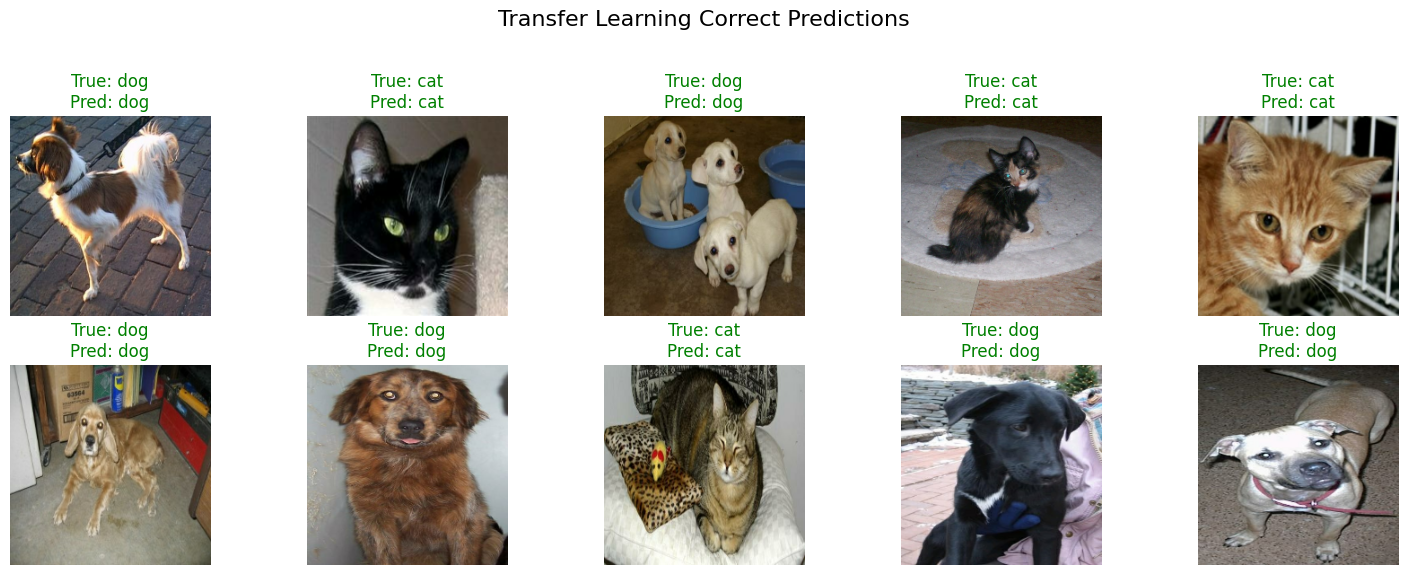

In [34]:
# Filter for correct predictions
correct_transfer_indices = np.where(sample_true_labels_transfer.flatten() == transfer_sample_predicted_classes)[0]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(correct_transfer_indices[:10]): # Show up to 10 correct predictions
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images_transfer[idx])
    true_label_name_transfer = transfer_class_names[sample_true_labels_transfer[idx]]
    predicted_label_name_transfer = transfer_class_names[transfer_sample_predicted_classes[idx]]
    plt.title(f"True: {true_label_name_transfer}\nPred: {predicted_label_name_transfer}", color='green')
    plt.axis('off')
plt.suptitle('Transfer Learning Correct Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Contoh Prediksi Salah Transfer Learning

In [35]:
# Filter for incorrect predictions
incorrect_transfer_indices = np.where(sample_true_labels_transfer.flatten() != transfer_sample_predicted_classes)[0]

plt.figure(figsize=(15, 6))
for i, idx in enumerate(incorrect_transfer_indices[:10]): # Show up to 10 incorrect predictions
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images_transfer[idx])
    true_label_name_transfer = transfer_class_names[sample_true_labels_transfer[idx]]
    predicted_label_name_transfer = transfer_class_names[transfer_sample_predicted_classes[idx]]
    plt.title(f"True: {true_label_name_transfer}\nPred: {predicted_label_name_transfer}", color='red')
    plt.axis('off')
plt.suptitle('Transfer Learning Incorrect Predictions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<Figure size 1500x600 with 0 Axes>

## Tabel Perbandingan Lengkap

In [36]:
display(comparison)

,Aspek,CNN,Transfer Learning
0,Testing Accuracy,0.718800,0.983954
1,Training Time,603.340365,2552.012980


# Kesimpulan Awal

Berdasarkan hasil eksperimen, dilakukan perbandingan antara CNN from Scratch dan Transfer Learning menggunakan beberapa metrik evaluasi seperti accuracy, loss, confusion matrix, dan waktu pelatihan. Hasil ini akan dianalisis lebih lanjut pada laporan.